In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.pipelines.hybrid_resnet50_pipeline import HybridResNet50_pipeline

import pandas as pd
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor


In [3]:
all_results = []
patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")
task_name= "multiclase"
task_config= TASKS[task_name]
patches_task = assign_task_labels(patches_df_full, task_config)

lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)
resnet50_model= HybridResNet50_pipeline(df = patches_task, case= Case.PATCH, extractor= extractor)


[INFO] HybridResNet50_pipeline inicializado:
  - 5290 muestras en df
  - 5290 descriptores indexados por match_key
  - Dimensión handcrafted: 40


Use weighted cross entropy: False

EXPERIMENTO K-FOLD: hybrid_resnet50_multiclase_no_augmentation
Total patchs: 5290
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 3709 patchs (217 cálculos)
  Val:   406 patchs (32 cálculos)
  Test:  1175 patchs (62 cálculos)
Device: cuda
Trainable parameters: 536,581
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.9867 acc=0.6464 f1=0.6370 | val: loss=0.9294 acc=0.6330 f1=0.6046 | lr=1.00e-04 | 11.3s
Epoch   2/30 | train: loss=0.7387 acc=0.7219 f1=0.7096 | val: loss=0.8568 acc=0.6478 f1=0.6165 | lr=1.00e-04 | 10.9s
Epoch   3/30 | train: loss=0.6533 acc=0.7492 f1=0.7397 | val: loss=0.8173 acc=0.6601 f1=0.6344 | lr=1.00e-04 | 10.9s
Epoch   4/30 | train: loss=0.6240 acc=0.7611 f1=0.7534 | val: loss=0.8155 acc=0.6502 f1=0.6303 | lr=1.00e-04 | 10.8s
Epoch   5/30 | train: loss=0.5907 acc=0.7741 f1=0.7690 | val: loss=0.8031 acc=0.6675 f1=0.6487 | lr=1.00e-04 | 10.9s
Epoch   6/30 | train: loss=0.5550 acc=0.

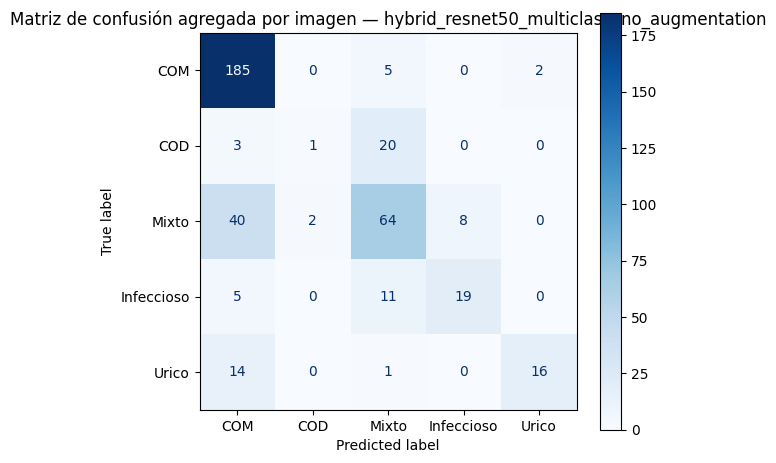

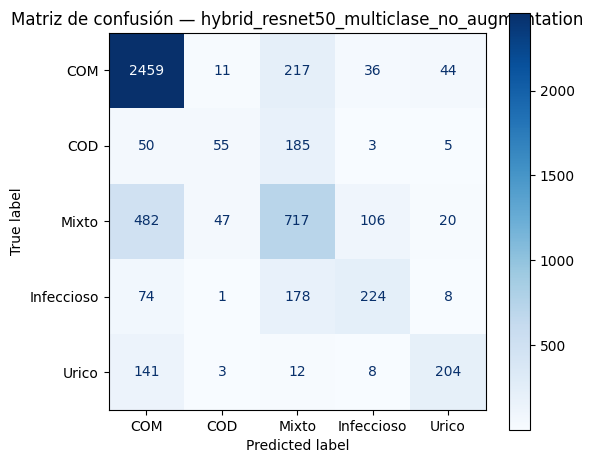


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6904 ± 0.0221
  auc_weighted: 0.8804 ± 0.0088
  f1_weighted: 0.6733 ± 0.0249
  precision_weighted: 0.6940 ± 0.0213
  recall_weighted: 0.6904 ± 0.0221


In [4]:
config = {
        "name": f"hybrid_resnet50_{task_name}_no_augmentation",
        "output_dir": f"experiments/hybrid_resnet50/hybrid_resnet50_patches/resnet50_{task_name}_no_augmentation",
        "class_names": task_config["class_names"],
        "batch_size": 16,
        }
        

result = resnet50_model.run_model(config, show_fold_metrics= True)
all_results.append(result)

CON PATCHES AUMENTADOS

In [3]:
patches_df_augmented = pd.read_csv(f"experiments/patches_{PATCH_SIZE}/multiclass_metadata_balanced.csv")
task_name= "multiclase"
task_config= TASKS[task_name]
patches_task = assign_task_labels(patches_df_augmented, task_config)

resnet50_model= HybridResNet50_pipeline(df = patches_task, case= Case.PATCH, extractor= extractor)


[INFO] HybridResNet50_pipeline inicializado:
  - 13835 muestras en df
  - 13835 descriptores indexados por match_key
  - Dimensión handcrafted: 40


Use weighted cross entropy : False

EXPERIMENTO K-FOLD: hybrid_resnet50_multiclase_with_augmentation
Total patchs: 13835
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 9458 patchs (211 cálculos)
  Val:   1640 patchs (37 cálculos)
  Test:  2737 patchs (63 cálculos)
Device: cuda
Trainable parameters: 536,581
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.9364 acc=0.6482 f1=0.6423 | val: loss=0.9636 acc=0.6183 f1=0.6234 | lr=1.00e-04 | 22.8s
Epoch   2/30 | train: loss=0.6987 acc=0.7439 f1=0.7409 | val: loss=0.9569 acc=0.5915 f1=0.6002 | lr=1.00e-04 | 22.4s
Epoch   3/30 | train: loss=0.6227 acc=0.7669 f1=0.7648 | val: loss=1.0209 acc=0.5530 f1=0.5550 | lr=1.00e-04 | 22.4s
Epoch   4/30 | train: loss=0.5665 acc=0.7862 f1=0.7845 | val: loss=1.0209 acc=0.5561 f1=0.5605 | lr=1.00e-04 | 22.4s
Epoch   5/30 | train: loss=0.5287 acc=0.8002 f1=0.7984 | val: loss=1.0272 acc=0.5561 f1=0.5596 | lr=1.00e-04 | 22.4s
Epoch   6/30 | train: loss=0.5017 a

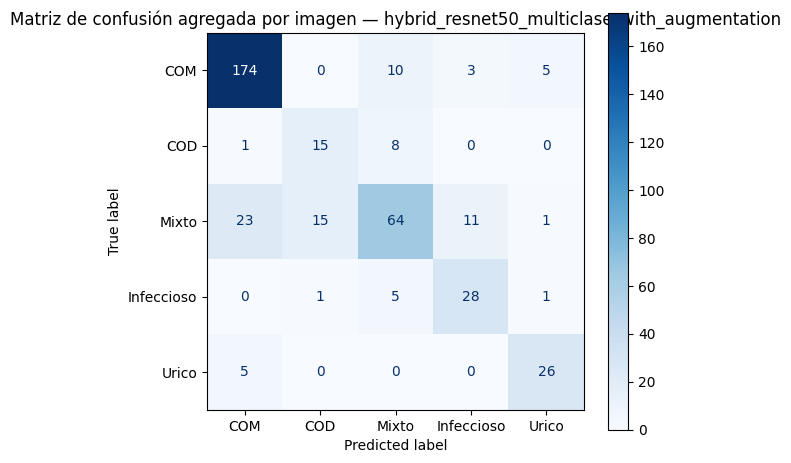

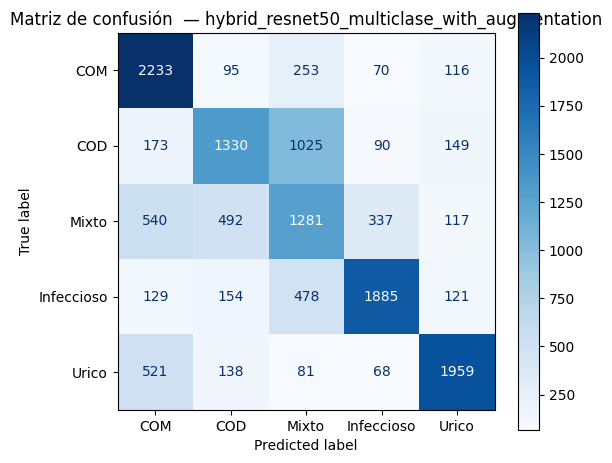


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6300 ± 0.0478
  auc_weighted: 0.8872 ± 0.0274
  f1_weighted: 0.6294 ± 0.0481
  precision_weighted: 0.6497 ± 0.0385
  recall_weighted: 0.6300 ± 0.0478


NameError: name 'all_results' is not defined

In [4]:
config = {
        "name": f"hybrid_resnet50_{task_name}_with_augmentation",
        "output_dir": f"experiments/hybrid_resnet50/hybrid_resnet50_patches/hybrid_resnet50_{task_name}_with_augmentation",
        "class_names": task_config["class_names"],
        "batch_size": 16,
        }
        

result = resnet50_model.run_model(config, show_fold_metrics= True)
